In [27]:

# 1. IMPORT LIBRARIES
# ==============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors  # <-- FIX ERROR
import folium
import matplotlib.cm as cm
import matplotlib.colors as colors


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
df = pd.read_excel("/content/drive/MyDrive/PRAKTIKUM/praktikum11/data/Dataset gps.xlsx")
print("Data berhasil dibaca:")
print(df.head())

Data berhasil dibaca:
   latitude  longitude
0    -69147    1076098
1    -69146    1076097
2    -69148    1076099
3    -69150    1076100
4    -69145    1076096


In [30]:
# 3. PREPROCESSING
#    Normalisasi latitude & longitude
df['latitude'] = df['latitude'] / 10000
df['longitude'] = df['longitude'] / 10000

coords = df[['latitude', 'longitude']].values
coords_rad = np.radians(coords)

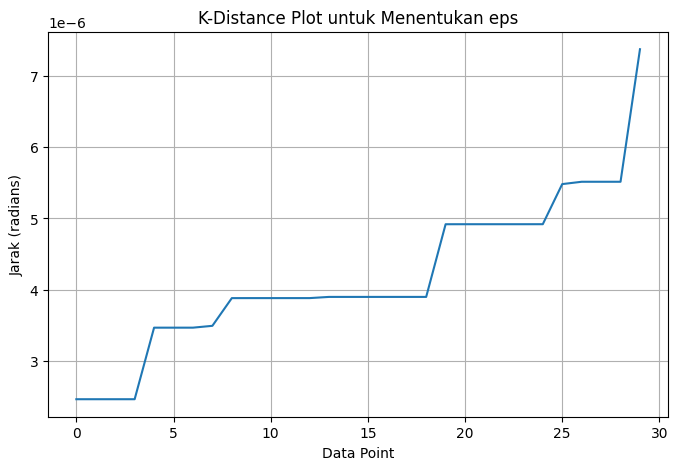

Gunakan grafik di atas untuk melihat 'siku' => nilai eps ideal.


In [31]:
# 4. PENENTUAN eps MENGGUNAKAN K-DISTANCE PLOT
neighbors = NearestNeighbors(n_neighbors=4, metric='haversine')
neighbors_fit = neighbors.fit(coords_rad)
distances, indices = neighbors_fit.kneighbors(coords_rad)
distances = np.sort(distances[:, 3])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Plot untuk Menentukan eps")
plt.xlabel("Data Point")
plt.ylabel("Jarak (radians)")
plt.grid(True)
plt.show()

print("Gunakan grafik di atas untuk melihat 'siku' => nilai eps ideal.")

In [32]:
# 5. PARAMETER eps & min_samples
R = 6371  # radius bumi (km)
eps_meters = 50          # target 50 meter
eps_rad = (eps_meters/1000) / R
min_samples = 3

print(f"eps (radian): {eps_rad}")
print(f"min_samples: {min_samples}")

eps (radian): 7.848061528802386e-06
min_samples: 3


In [33]:
# 6. IMPLEMENTASI DBSCAN
db = DBSCAN(
    eps=eps_rad,
    min_samples=min_samples,
    metric='haversine'
).fit(coords_rad)

df['cluster'] = db.labels_

In [34]:
# 7. ANALISIS CLUSTER & NOISE
print("\n=== Jumlah Data per Cluster ===")
print(df['cluster'].value_counts().sort_index())

noise = (df['cluster'] == -1).sum()
print(f"\nJumlah Noise: {noise}")


=== Jumlah Data per Cluster ===
cluster
0    10
1    10
2    10
Name: count, dtype: int64

Jumlah Noise: 0


/tmp/ipython-input-2473653277.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Spectral')


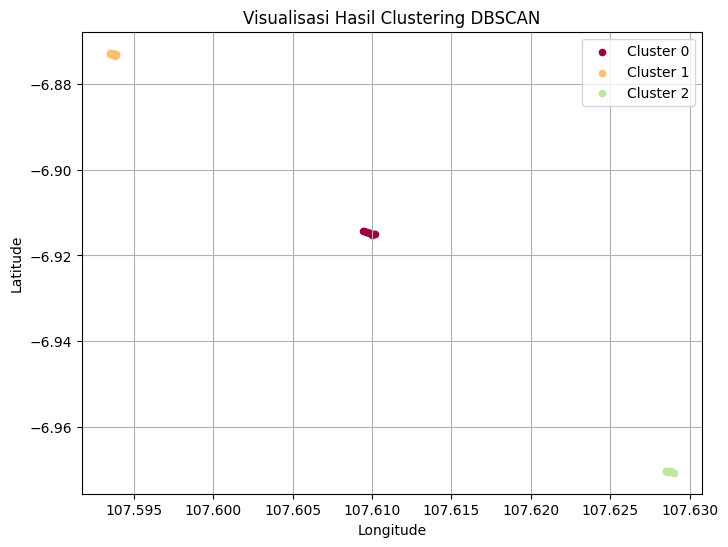

In [35]:
# 8. VISUALISASI SCATTER PLOT CLUSTERING
unique_labels = set(df['cluster'])
cmap = cm.get_cmap('Spectral')
n_colors = len(unique_labels)
palette = [colors.rgb2hex(cmap(i / n_colors)) for i in range(n_colors)]

color_map = {label: palette[i] for i, label in enumerate(unique_labels)}
color_map[-1] = "#000000"  # noise = hitam

plt.figure(figsize=(8,6))
for label in unique_labels:
    temp = df[df['cluster'] == label]
    plt.scatter(temp['longitude'], temp['latitude'],
                s=20, color=color_map[label],
                label=f"Cluster {label}")

plt.title("Visualisasi Hasil Clustering DBSCAN")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# 9. VISUALISASI PETA GPS (FOLIUM)
map_center = [df['latitude'].mean(), df['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=15)

for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_map[row['cluster']],
        fill=True,
        fill_color=color_map[row['cluster']],
        fill_opacity=0.9,
        tooltip=f"Cluster: {row['cluster']}"
    ).add_to(m)

print("\n=== Peta Interaktif ===")

# WAJIB supaya peta tampil
m



=== Peta Interaktif ===


In [37]:
# 10. EXPORT HASIL KE CSV
# ==============================================
output_path = "/content/drive/MyDrive/PRAKTIKUM/praktikum11/data/hasil_dbscan.csv"
df.to_csv(output_path, index=False)

print("\nHasil clustering telah disimpan ke:")
print(output_path)


Hasil clustering telah disimpan ke:
/content/drive/MyDrive/PRAKTIKUM/praktikum11/data/hasil_dbscan.csv
